In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#World Constants
g = 9.81


In [3]:
# Rider Parameters 
m = 75 #Total mass in KG of rider and bike
CdA = 0.26 # Cd= drag coefficent, A = frontal area
Crr = 0.004 #Rolling Resistance coeficcent
v_max = 30 #Cap of rider speed 


#Rider Power Parameters
P_max = 400
P_threshold = 300 #Above this power threshold fatigue will build
P_base = 250 #Default power output on flat ground

hill_factor = 800 #How much does rider change power output due to hills

fatigue_rate = 0.05 #how fast fatigue builds when rider is above threshold
recovery_rate = 0.01 #how fast fatigue recovers when below threshold
fatigue_impact = 0.4 #How much fatigue reduces max power




In [4]:
# Course Segment Inputs
a_density = 1.225 #Air density
 #hw = 1.0 #Headwind in m/s
 #grad = 0.03 #Steepness of course in degress from flat (pos = uphill, neg = downhill)
 #total_distance = 2000.0 #Distance of course in meters, these three inputs are for a constant course, so are only relevant for code testing

wind_map = {"low" : 0.5, "medium" : 1.0, "high": 2.0} #Wind map dictionary that translate wind exposure from a word to a int

#in order the paramters are name, segment_distance (in meters), grade_percent, turn_penalty, wind_exposure, where both turn penalty and 
#wind exposure are choosen based on analysis of given course segment
lap = [
    # --- Speedway section ---
    ("Speedway start straight",              1480,  0.0, 0, "low"),
    ("Speedway initial descent",              620, -1.5, 0, "low"),
    ("Speedway exit descent (steep)",         600, -3.5, 2, "low"),

    # --- Road descent to valley ---
    ("Track exit descent upper",             1200, -3.2, 2, "low"),
    ("Track exit descent lower",             1000, -2.8, 2, "low"),
    ("Flat valley bottom / road junction",    500,  0.2, 5, "low"),

    # --- Main 5km climb ---
    ("Lower slopes of main climb",           1000,  2.5, 0, "medium"),
    ("Main climb lower-mid",                 1000,  3.1, 0, "medium"),
    ("Middle of main climb (steepest)",       900,  5.8, 0, "medium"),
    ("Upper main climb",                      900,  4.9, 0, "high"),
    ("Main climb final steep pitch",          400,  8.9, 0, "high"),
    ("Summit plateau / time check",           300,  1.0, 0, "high"),

    # --- Descent back to Speedway ---
    ("Descent from summit (fast upper)",     1000, -5.1, 0, "high"),
    ("Descent mid section",                  1000, -4.6, 0, "medium"),
    ("Sweeping bends lower descent",          800, -4.6, 3, "medium"),
    ("Lower descent toward Speedway",         800, -2.8, 2, "low"),
    ("Final flat approach to Speedway",       400, -1.5, 0, "low"),

    # --- Speedway re-entry and pit lane climb ---
    ("Flat approach to Speedway entrance",    600,  0.4, 6, "low"),
    ("Pit lane climb (lower ramp)",           400,  4.2, 0, "low"),
    ("Pit lane climb (steep upper)",          300,  8.9, 0, "low"),
    ("Pit lane climb (upper ramp)",           400,  6.1, 3, "low"),

    # --- Speedway infield finish loop ---
    ("Speedway infield rolling section",      800,  1.2, 0, "low"),
    ("Back straight (flat sheltered)",       1000,  0.0, 0, "low"),
    ("Final bend onto main straight",         400,  0.3, 4, "low"),
    ("Main straight to finish",              1480, -0.5, 0, "low"),
    ("Finish line buffer",                    200,  0.0, 0, "low"),
]

course = [(name + " (lap 1)", d, g, t, w) for name, d, g, t, w in lap] + \
         [(name + " (lap 2)", d, g, t, w) for name, d, g, t, w in lap]


In [5]:
#Trial Assumptions
dt = 1.0 #Timesteps

In [6]:
def simulate(params, return_full=False):
    hill_factor, flat_boost = params
    """
    Run the simulation with a given hill_factor, and flat_boost. 
    If return_full=False, returns only total time (for the optimizer).
    If return_full=True, returns time plus all logged arrays (for plotting). 

    We do this since we only need to retunr all of the data when we want to plot, since the optimizer may have to run the code a lot
    we dont 
    """

    v = 0.0 #Starting speed = 0
    distance = 0.0 #Starting Distance = 0
    t = 0 #Starting time = 0
    fatigue = 0 #starting fatigue = 0
    
    times = []
    speeds = []
    distances = []
    drags = []
    fatigues = []
    gradients = []
    powers = []
    
    for name, segment_distance, grade_percent, turn_penalty, wind_exposure in course:
        grad = np.arctan(grade_percent / 100) #Since we know the gradient in % this converts it into radians
        hw = wind_map[wind_exposure] #converts wind_exposure to a numerical value usuing the wind_map dictionary
        t += turn_penalty*2 #applies a set extra time cost due to the turn penalty, this is a simplificaiton due to the fact that are race segement 
                                #are so long, so it would not make sense to account for specific corners, rather just a general time penalty
                                #for how curvy the segment is
    
        segment_start = distance
    
        
        while distance - segment_start < segment_distance: #accounts for the difference of the segment
            if grad > 0.01:  # while climbing this is the target power, will be higher when going up hill, lower downhill
                P_target = max(50, P_base + hill_factor * grad)
            else: # while flat or descent this is the target power, the flat boost allows for the riders power on the flat to vary
                P_target = max(50, P_base + flat_boost)
            
            P_cap = P_max * (1 - fatigue_impact * fatigue) #max power output based on how fatigued the rider is
            P_output = min(P_target, P_cap) #how much the power the rider will output, cannot be greater than P_cap
            
            if P_output > P_threshold: #if the P_output is higher than the riders given power threshold
                fatigue = fatigue + fatigue_rate * (((P_output - P_threshold) / P_threshold)**2 * dt) #squared exceeding term makes fatigue build more if rider
                                                                                        #exceed by large ammounts, /P_threshold so value does not exceed 1
                fatigue = min(fatigue, 1.0) #Makes sure fatigure does not exceed 1.0
            else:
                fatigue = max(0, fatigue - recovery_rate * dt) #fatigue recovery if rider is not in fatigue zone
                
            Rider_force_output = P_output / max(v, 0.50) # power = force * velocity, so force = power/velocity, max is to prevent the divide by 0 
                                                         # since rider starts from rest, 0.5 prevents the function from spiking to a large value
                                                            #when v is very small
            drag = 0.5 * a_density * CdA * ((v + hw)**2) #physics based drag equation
            gravity = m * g * np.sin(grad) #physics gravity equation
            rolling_resistance = Crr * m * g * np.cos(grad)
        
            Rider_Net_force = Rider_force_output - drag - gravity - rolling_resistance
        
            v = max(0, min(v + ((dt/m) * Rider_Net_force), v_max)) #the max prevents v going below 0
                                                                    #min prevents v going above v_max
            distance = distance + v *dt
            t = t + dt
        
            times.append(t)
            speeds.append(v)
            distances.append(distance)
            drags.append(drag)
            powers.append(P_output)
            fatigues.append(fatigue)
            gradients.append(grade_percent)

    if return_full:
        return t, fatigue, times, speeds, distances, drags, powers, fatigues, gradients
    return t

In [7]:
from scipy.optimize import minimize 

result = minimize(simulate, x0=[800, 50], method='Nelder-Mead', #this functions allows us to minimize the code according to the variables                                                   
                  bounds=[(0, 2000), (0, 100)])                  #with the approval of professor johnson I do not really understand how it works, details about the general algorithm will
                                                                    #be included in the paper
best_hill_factor, best_flat_boost = result.x              
best_time = result.fun
baseline_time = simulate((800, 0))

print("Baseline hill_factor : 800")
print("Baseline flat_boost : 0")
print("Optimal hill_factor  : " + str(round(best_hill_factor, 1)))
print("Optimal flat_boost  : " + str(round(best_flat_boost, 1)))
print("Baseline time : " + str(round(baseline_time/60, 1)) + " min  " + str(round(baseline_time%60)) + " sec")
print("Optimal time  : " + str(round(best_time/60, 1)) + " min  " + str(round(best_time%60)) + " sec")
print("Time saved    : " + str(round(baseline_time - best_time, 1)) + " sec")

Baseline hill_factor : 800
Baseline flat_boost : 0
Optimal hill_factor  : 1868.8
Optimal flat_boost  : 49.2
Baseline time : 69.2 min  15 sec
Optimal time  : 64.4 min  22 sec
Time saved    : 293.0 sec


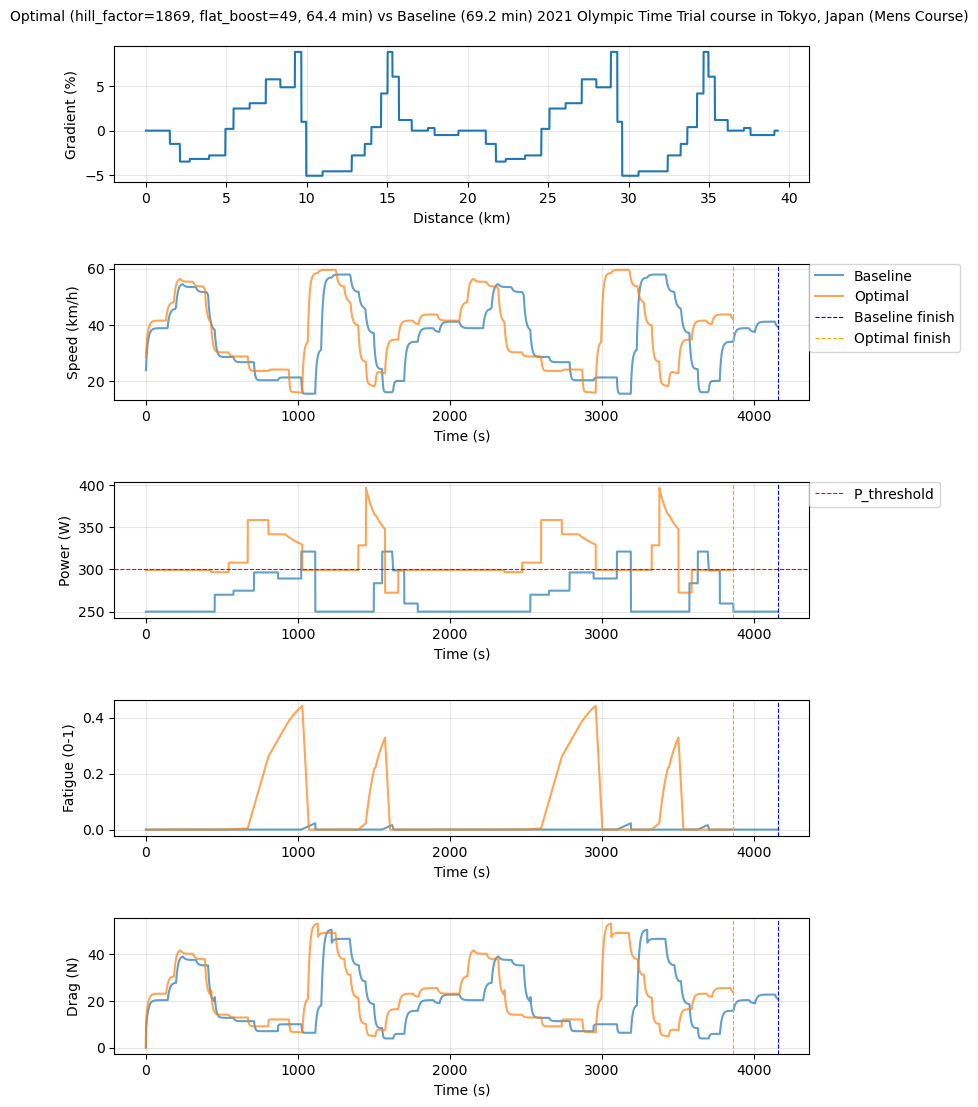

In [8]:
t_opt,  fat_opt,  times_opt,  speeds_opt,  distances_opt,  drags_opt,  powers_opt,  fatigues_opt,  gradients_opt  = simulate((best_hill_factor, best_flat_boost), return_full=True) #simulates the code with full data so we can plot it
t_base, fat_base, times_base, speeds_base, distances_base, drags_base, powers_base, fatigues_base, gradients_base = simulate((800, 0), return_full=True)

fig, ax = plt.subplots(5, 1, figsize=(10, 12))
fig.suptitle("Optimal (hill_factor=" + str(round(best_hill_factor)) + ", flat_boost=" + str(round(best_flat_boost)) + ", " + str(round(best_time/60, 1)) + " min) vs Baseline (" + str(round(baseline_time/60, 1)) + " min)" + ' 2021 Olympic Time Trial course in Tokyo, Japan (Mens Course)', fontsize=10, y=0.98)

ax[0].plot([d / 1000 for d in distances_base], gradients_base, label='Baseline')
ax[0].set_ylabel("Gradient (%)")
ax[0].set_xlabel("Distance (km)")
ax[0].grid(alpha=0.3)

ax[1].plot(times_base, [s * 3.6 for s in speeds_base], label='Baseline', alpha=0.7)
ax[1].plot(times_opt,  [s * 3.6 for s in speeds_opt],  label='Optimal',  alpha=0.7)
ax[1].axvline(t_base, color='blue',   linestyle='--', linewidth=0.8, label='Baseline finish')
ax[1].axvline(t_opt,  color='orange', linestyle='--', linewidth=0.8, label='Optimal finish')
ax[1].set_ylabel("Speed (km/h)")
ax[1].set_xlabel("Time (s)")
ax[1].legend(loc='upper left', bbox_to_anchor=(1, 1), borderaxespad=0)
ax[1].grid(alpha=0.3)

ax[2].plot(times_base, powers_base, alpha=0.7)
ax[2].plot(times_opt,  powers_opt,  alpha=0.7)
ax[2].axvline(t_base, color='blue',   linestyle='--', linewidth=0.8)
ax[2].axvline(t_opt,  color='orange', linestyle='--', linewidth=0.8)
ax[2].axhline(P_threshold, color='red', linestyle='--', linewidth=0.8, label='P_threshold')
ax[2].legend(loc='upper left', bbox_to_anchor=(1, 1), borderaxespad=0)
ax[2].set_ylabel("Power (W)")
ax[2].set_xlabel("Time (s)")
ax[2].grid(alpha=0.3)

ax[3].plot(times_base, fatigues_base, alpha=0.7)
ax[3].plot(times_opt,  fatigues_opt,  alpha=0.7)
ax[3].axvline(t_base, color='blue',   linestyle='--', linewidth=0.8)
ax[3].axvline(t_opt,  color='orange', linestyle='--', linewidth=0.8)
ax[3].set_ylabel("Fatigue (0-1)")
ax[3].set_xlabel("Time (s)")
ax[3].grid(alpha=0.3)

ax[4].plot(times_base, drags_base, alpha=0.7)
ax[4].plot(times_opt,  drags_opt,  alpha=0.7)
ax[4].axvline(t_base, color='blue',   linestyle='--', linewidth=0.8)
ax[4].axvline(t_opt,  color='orange', linestyle='--', linewidth=0.8)
ax[4].set_ylabel("Drag (N)")
ax[4].set_xlabel("Time (s)")
ax[4].grid(alpha=0.3)

fig.subplots_adjust(right=0.82, hspace=0.6, top=0.95)
plt.show()